# Predicting Calories Burned During Workouts
### Data Science Engineering — Team Project COMP 381
### Dataset: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset
### Members:
### Yuvraj Singh Goraya
### Navpreet Singh

This notebook analyzes the **Gym Members Exercise Dataset** to find which factors most
influence calories burned during a workout and builds a model to predict calorie burn
from workout and body metrics.

**Dataset:** Gym Members Exercise Dataset (Kaggle)- ~973 members, 15 features.


## 1. Setup and Load Data

In [2]:
# Core libraries for data handling, visualization and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv("gym_members_exercise_tracking.csv")
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## 2. Explore the Data
Check the size, data types and basic statistics before any analysis.

In [3]:
# Shape
print("Rows, Columns:", df.shape)

df.info()

Rows, Columns: (973, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/w

In [4]:
# Summary statistics for the numeric columns
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## 3. Clean the Data
The dataset is well-prepared, so we just confirm there are no missing values or duplicates.

In [5]:
# Counts missing values per column
print("Missing values:\n", df.isnull().sum())

# Counts and removes any duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Missing values:
 Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Duplicate rows: 0


## 4. Exploratory Data Analysis (EDA)
We visualize the data to understand patterns before modeling.

**4.1 How are calories burned distributed?**

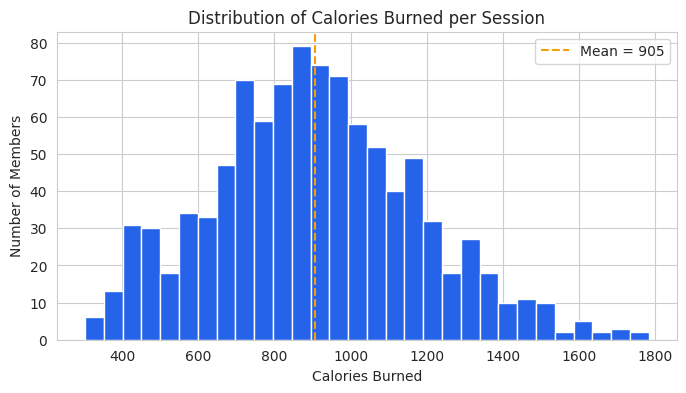

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df["Calories_Burned"], bins=30, color="#2563eb", edgecolor="white")
plt.axvline(df["Calories_Burned"].mean(), color="#f59e0b", linestyle="--",
            label=f"Mean = {df['Calories_Burned'].mean():.0f}")
plt.title("Distribution of Calories Burned per Session")
plt.xlabel("Calories Burned"); plt.ylabel("Number of Members")
plt.legend(); plt.show()

**4.2 Which features relate to calories burned?**
A correlation heatmap shows the strength of relationships between numeric features.

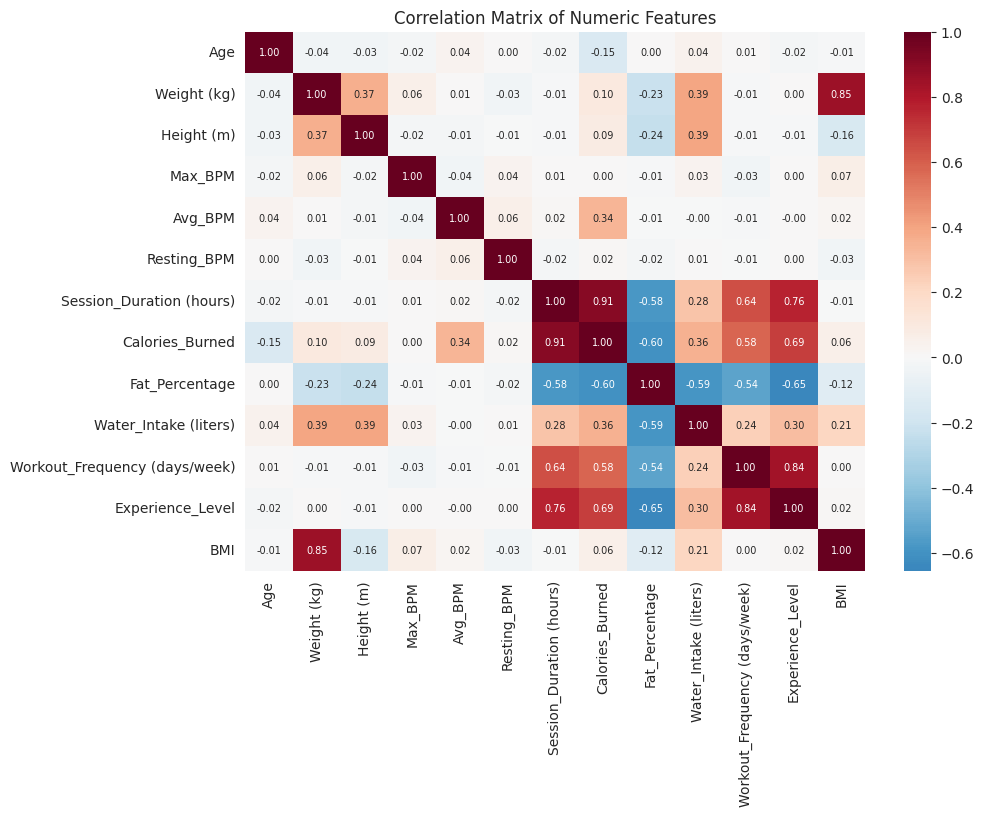

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, annot_kws={"size": 7})
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [8]:
# Ranking features by how strongly they correlate with calories burned
df.select_dtypes("number").corr()["Calories_Burned"].sort_values(ascending=False)

,Calories_Burned
Calories_Burned,1.000000
Session_Duration (hours),0.908140
Experience_Level,0.694129
Workout_Frequency (days/week),0.576150
Water_Intake (liters),0.356931
Avg_BPM,0.339659
Weight (kg),0.095443
Height (m),0.086348
BMI,0.059761
Resting_BPM,0.016518


**4.3 The strongest relationship: session duration vs calories burned**

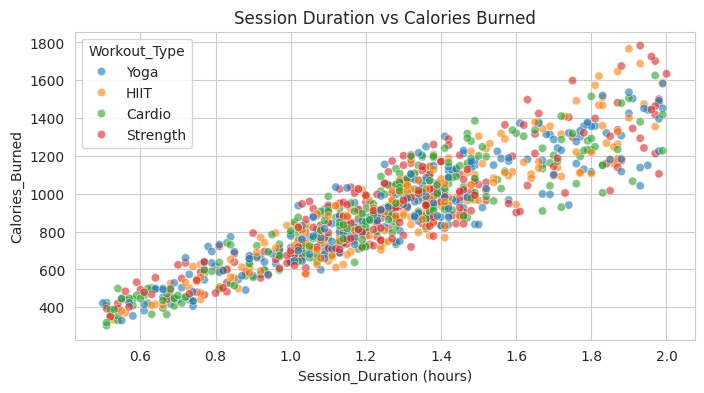

In [9]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="Session_Duration (hours)", y="Calories_Burned",
                hue="Workout_Type", alpha=0.6)
plt.title("Session Duration vs Calories Burned")
plt.show()

**4.4 Do different workout types burn different amounts?**

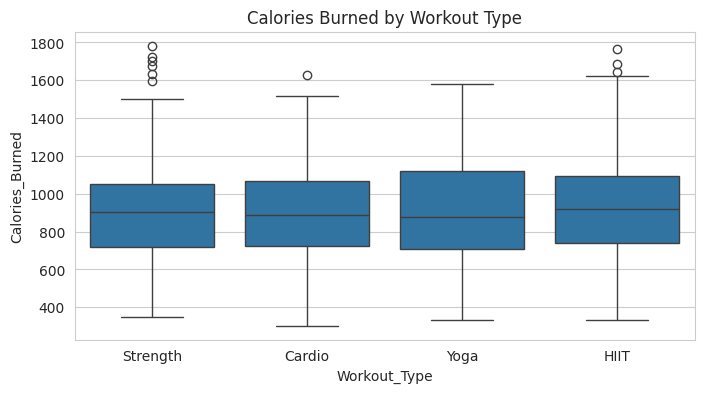

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Workout_Type", y="Calories_Burned",
            order=["Strength", "Cardio", "Yoga", "HIIT"])
plt.title("Calories Burned by Workout Type")
plt.show()

## 5. Prepare Data for Modeling
We converted text columns (Gender, Workout_Type) into numbers using one-hot encoding and
then split into features (X) and target (y).

In [11]:
data = pd.get_dummies(df, columns=["Gender", "Workout_Type"], drop_first=True)

# X = all inputs, y = what we want to predict
X = data.drop(columns=["Calories_Burned"])
y = data["Calories_Burned"]

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features so they are on a comparable range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Build and Evaluate Models
We try two models and compared them:
- **Linear Regression** - simple, interpretable baseline.
- **Neural Network (MLP)** - a more flexible model that can capture non-linear patterns.

We measure performance with R² (higher is better), RMSE and MAE (lower is better).

In [12]:
def evaluate(name, y_true, y_pred):
    print(f"{name}")
    print(f"  R2   = {r2_score(y_true, y_pred):.4f}")
    print(f"  RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"  MAE  = {mean_absolute_error(y_true, y_pred):.2f}\n")

In [13]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
evaluate("Linear Regression", y_test, pred_lr)

# Model 2: Neural Network
nn = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000,
                  random_state=42, early_stopping=True)
nn.fit(X_train_scaled, y_train)
pred_nn = nn.predict(X_test_scaled)
evaluate("Neural Network", y_test, pred_nn)

Linear Regression
  R2   = 0.9803
  RMSE = 40.57
  MAE  = 30.27

Neural Network
  R2   = 0.9385
  RMSE = 71.65
  MAE  = 55.46



**6.1 Which features matter most?** For a linear model, the standardized coefficients show each feature's effect on calories burned.

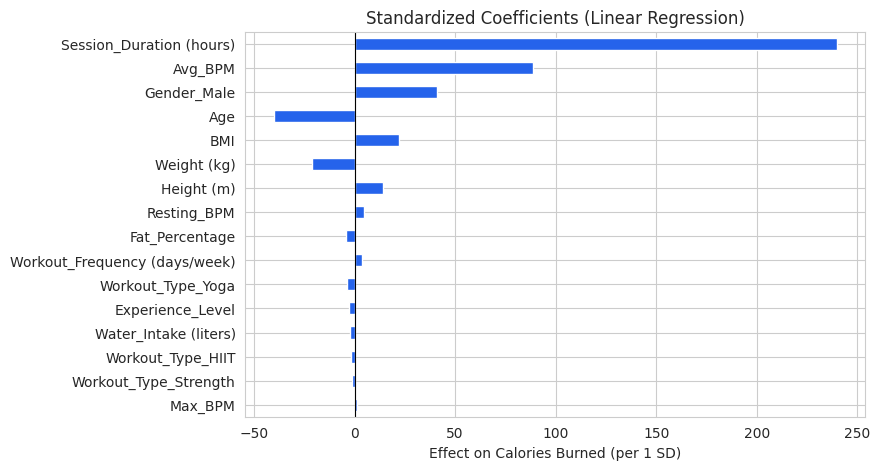

In [14]:
# Coefficients from the linear model
coefs = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs)
plt.figure(figsize=(8, 5))
coefs.plot(kind="barh", color="#2563eb")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Standardized Coefficients (Linear Regression)")
plt.xlabel("Effect on Calories Burned (per 1 SD)")
plt.show()

**6.2 How good are the predictions?** Points near the dashed line = accurate predictions.

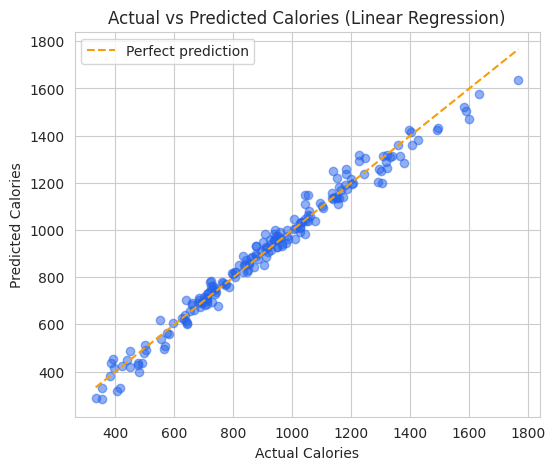

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_lr, alpha=0.5, color="#2563eb")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "--", color="#f59e0b", label="Perfect prediction")
plt.title("Actual vs Predicted Calories (Linear Regression)")
plt.xlabel("Actual Calories"); plt.ylabel("Predicted Calories")
plt.legend(); plt.show()

## 7. Conclusion

- **Session duration** is by far the strongest predictor of calories burned, followed by
  **average heart rate** (intensity).
- **Fat percentage** is negatively related--> leaner members tend to burn more per session.
- **Linear Regression** predicts calories burned very accurately (**R² ≈ 0.98**) and actually
  **outperforms the Neural Network** here because calorie burn is mostly a linear function of
  how long and how intensely a person trains. A more complex model adds little when the
  underlying relationship is already linear.

**Takeaway:** To increase calorie burn, the most effective levers are training *longer*
and at a *higher average heart rate*, rather than choosing a specific workout type.
